In [1]:
import os
import time
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from dust_extinction.parameter_averages import F99
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, median_abs_deviation

In [2]:
def add_filters(df):
    df = df.copy()
    filter_cols = []
    for i in df["Filter"].unique():
        name = f"Filter_{i}_flux"
        filter_cols += [name, f"{name}_err"]
        df[[name,f"{name}_err"]] = df[["Flux","Flux_err"]]
        df.loc[df['Filter'] != i, [f"{name}_err",name]] = 0
    df.drop(columns=["Filter", "Flux_err", "Flux"], inplace=True)
    return df, filter_cols

def combine_filters(df, filter_cols):
    return (
        df.set_index(['object_id', 'Time (MJD)'])[filter_cols]
        .replace(0, np.nan)
        .groupby(level=[0, 1])
        .first()
        .fillna(0)
        .reset_index()
    )

def find_dict(filter_cols, filters):
    new_dict = {}
    for col in filter_cols:
        for f, wl in filters.items():
            if f"Filter_{f}" in col:
                new_dict[col] = wl
    return new_dict

def EBV_corr_mod(df, filter_cols, filters, ebv_col="EBV", Rv=3.1):
    df = df.copy()
    eff_filters_dict = find_dict(filter_cols, filters)
    law = F99(Rv=Rv)
    for col, wl in eff_filters_dict.items():
        ebv = df[ebv_col]
        flux = df[col]
        Av = ebv * Rv
        wl_array_micron = np.full_like(ebv, wl, dtype=float) * 1e-4 * u.micron
        A_lambda = law(wl_array_micron) * Av
        df[col] = flux * 10**(A_lambda / 2.5)
        df[f"A_lambda_{col}"] = A_lambda
    return df

def merge_features(df, df_merge):
    df = df.copy()
    merged = pd.merge(df, df_merge, on="object_id")
    return merged

In [3]:
orig_dir = f'{os.getcwd().replace("\\", "/")}/Data/Actual Mallorn data'
new_dir = f'{os.getcwd().replace("\\", "/")}/Data/Porcessed Data'

In [4]:
train = pd.read_csv(f"{orig_dir}/train_log.csv")
train.drop(columns=["Z_err","English Translation"], inplace=True)

test = pd.read_csv(f"{orig_dir}/test_log.csv")
test.drop(columns=["Z_err","SpecType","English Translation"], inplace=True)

filters_eff = {"u": 3641, "g": 4704, "r": 6155, "i": 7504, "z": 8695, "y": 10056}

In [5]:
df = pd.read_csv(f"{orig_dir}/split_01/train_full_lightcurves.csv")

t1 = time.time()
df, filter_cols = add_filters(df)
print("add_filters:", round(time.time() - t1,4),"s")

t2 = time.time()
df = combine_filters(df, filter_cols)
print("combine_filters:", round(time.time() - t2,4),"s")

t3 = time.time()
df = merge_features(df, train)
print("merge_train:", round(time.time() - t3,4),"s")

t4 = time.time()
df = EBV_corr_mod(df, filter_cols, filters_eff)
print("EBV_corr:", round(time.time() - t4,4),"s")

print("Final", round(time.time()-t1,4),"s")

add_filters: 0.0574 s
combine_filters: 0.0612 s
merge_train: 0.0114 s
EBV_corr: 0.0688 s
Final 0.2017 s


In [6]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(df.head())

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,Z,EBV,SpecType,split,target,A_lambda_Filter_z_flux,A_lambda_Filter_z_flux_err,A_lambda_Filter_r_flux,A_lambda_Filter_r_flux_err,A_lambda_Filter_y_flux,A_lambda_Filter_y_flux_err,A_lambda_Filter_i_flux,A_lambda_Filter_i_flux_err,A_lambda_Filter_g_flux,A_lambda_Filter_g_flux_err,A_lambda_Filter_u_flux,A_lambda_Filter_u_flux_err
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0,3.049,0.11,AGN,split_01,0,0.163728,0.163728,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0,3.049,0.11,AGN,split_01,0,0.163728,0.163728,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0,3.049,0.11,AGN,split_01,0,0.163728,0.163728,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0,3.049,0.11,AGN,split_01,0,0.163728,0.163728,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0,3.049,0.11,AGN,split_01,0,0.163728,0.163728,0.285117,0.285117,0.127223,0.127223,0.209783,0.209783,0.414976,0.414976,0.52232,0.52232


# Processing The Data And Applying Ebv Correction

In [7]:
all_dfs_train = []
all_dfs_test = []

for dirname, _, filenames in os.walk(orig_dir):
    for filename in filenames:
        if "split" in dirname:
            name = os.path.join(dirname, filename)
            df = pd.read_csv(name)
            df, filter_cols = add_filters(df)
            df = combine_filters(df, filter_cols)
            if "train" in name:
                df = merge_features(df, train)
                df = EBV_corr_mod(df, filter_cols, filters_eff)
                all_dfs_train.append(df)
            else:
                df = merge_features(df, test)
                df = EBV_corr_mod(df, filter_cols, filters_eff)
                all_dfs_test.append(df)

CNN_train = pd.concat(all_dfs_train, ignore_index=True)
CNN_train.to_csv(f"{new_dir}/CNN_train.csv", index=False)

CNN_test = pd.concat(all_dfs_test, ignore_index=True)
CNN_test.to_csv(f"{new_dir}/CNN_test.csv", index=False)
print("done")

done


# Train Validation Split

In [8]:
df = pd.read_csv(f"{new_dir}/CNN_train.csv")

A_lambda = [c for c in df.columns if "A_lambda" in c]
dropped =["split","EBV","Z"] + A_lambda
df.drop(columns=dropped+["target"], inplace=True)
cols = df.drop(columns=["object_id","Time (MJD)"]).columns.tolist()

def stratified_unique_split(df, target_col, object_id_col, test_size=0.2, random_state=42):
    unique_objs = df[[object_id_col, target_col]].drop_duplicates(subset=[object_id_col])

    train_objs, test_objs = train_test_split(
        unique_objs,
        test_size=test_size,
        stratify=unique_objs[target_col],
        random_state=random_state
    )

    train_df = df[df[object_id_col].isin(train_objs[object_id_col])]
    test_df = df[df[object_id_col].isin(test_objs[object_id_col])]

    return train_df, test_df

train_df, test_df = stratified_unique_split(df, target_col="SpecType", object_id_col="object_id", test_size=0.2)

train_df.to_csv(f"{new_dir+"/CNN_split"}/train_df.csv", index=False)
test_df.to_csv(f"{new_dir+"/CNN_split"}/test_df.csv", index=False)
print("done")

done


# XGB Version

In [9]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, average_precision_score

In [10]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(df.head())

,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err,SpecType
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0,AGN
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0,AGN
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0,AGN
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0,AGN
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0,AGN


In [11]:
main_cols = {
    "dt": "sum",
    "SpecType": "first",
    "Z": "first",
    "EBV": "first",
}


In [12]:
main_cols.keys()

dict_keys(['dt', 'SpecType', 'Z', 'EBV'])

In [13]:
df = CNN_train.copy()
df = df.sort_values(["object_id", "Time (MJD)"])
df["dt"] = df.groupby("object_id")["Time (MJD)"].diff()
df.fillna(0, inplace=True)

total_agg = df.copy()
total_agg = total_agg.groupby("object_id").agg(main_cols)
flux_cols = []
for c in df.columns:
    if ("Filter" in c) and ("err" not in c) and ("lambda" not in c):
        flux_cols.append(c)
flux_cols

['Filter_z_flux',
 'Filter_r_flux',
 'Filter_y_flux',
 'Filter_i_flux',
 'Filter_g_flux',
 'Filter_u_flux']

In [14]:
for col in flux_cols:
    mask = df[col] != 0
    df.loc[mask, col] = df.loc[mask, col] + 100

In [15]:
def slope(t, x):
    if len(x) < 2:
        return np.nan
    return np.polyfit(t, x, 1)[0]
def all_slopes_per_group(g, flux_cols, time_col="Time (MJD)"):
    results = {}
    t = g[time_col].values
    for col in flux_cols:
        x = g[col].values
        peak_idx = np.argmax(x)

        pre_slope = slope(t[:peak_idx+1], x[:peak_idx+1])
        post_slope = slope(t[peak_idx:], x[peak_idx:])

        results[f"{col}_slope_pre"] = pre_slope
        results[f"{col}_slope_post"] = post_slope
    return pd.Series(results)

In [16]:
def mask_nonzero(x, t):
    nz = x != 0
    return x[nz], t[nz]

def handle_few_points(col):
    features = [
        # basic stats
        "min","max","mean","std","var","median","skew","kurtosis",
        "n_obs","q05","q25","q75","q95","iqr","mad",
        # temporal + slopes
        "max_change","rise_time","decay_time","slope_pre","slope_post",
        # physical
        "rise_decay_ratio","time_above_median","duty_cycle",
        "post_peak_fraction","num_peaks","plaw_alpha","plaw_r2"
    ]
    return {f"{col}_{feat}": np.nan for feat in features}

def compute_basic_stats(col, x):
    q05, q25, q75, q95 = np.percentile(x, [5, 25, 75, 95])
    return {
        f"{col}_min": np.min(x),
        f"{col}_max": np.max(x),
        f"{col}_mean": np.mean(x),
        f"{col}_std": np.std(x, ddof=1),
        f"{col}_var": np.var(x, ddof=1),
        f"{col}_median": np.median(x),
        f"{col}_skew": skew(x, bias=False),
        f"{col}_kurtosis": kurtosis(x, bias=False),
        f"{col}_n_obs": len(x),
        f"{col}_q05": q05,
        f"{col}_q25": q25,
        f"{col}_q75": q75,
        f"{col}_q95": q95,
        f"{col}_iqr": q75 - q25,
        f"{col}_mad": median_abs_deviation(x, scale="normal")
    }

def compute_temporal_features(col, x, t, slope_fn):
    order = np.argsort(t)
    t = t[order]
    x = x[order]

    dx = np.diff(x)
    dt = np.diff(t)
    peak_idx = np.argmax(x)

    return {
        f"{col}_max_change": np.max(np.abs(dx / dt)),
        f"{col}_rise_time": t[peak_idx] - t[0],
        f"{col}_decay_time": t[-1] - t[peak_idx],
        f"{col}_slope_pre": slope_fn(t[:peak_idx + 1], x[:peak_idx + 1]),
        f"{col}_slope_post": slope_fn(t[peak_idx:], x[peak_idx:]),
        "peak_idx": peak_idx,
        "t_sorted": t,
        "x_sorted": x
    }

def compute_physical_features(col, x, t, peak_idx):
    features = {}
    median_x = np.median(x)
    denom = t[-1] - t[peak_idx]

    features[f"{col}_rise_decay_ratio"] = (t[peak_idx] - t[0]) / denom if denom > 0 else np.nan
    features[f"{col}_time_above_median"] = np.sum(np.diff(t) * (x[:-1] > median_x))
    features[f"{col}_duty_cycle"] = np.mean(x > median_x)
    features[f"{col}_post_peak_fraction"] = x[-1] / x.max() if x.max() != 0 else np.nan
    features[f"{col}_num_peaks"] = np.sum((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))

    # power-law decay
    t_post = t[peak_idx + 1:] - t[peak_idx]
    x_post = x[peak_idx + 1:]
    if len(x_post) >= 3 and np.all(x_post > 0):
        log_t = np.log(t_post)
        log_x = np.log(x_post)
        alpha = -np.polyfit(log_t, log_x, 1)[0]
        r2 = np.corrcoef(log_t, log_x)[0, 1] ** 2
        features[f"{col}_plaw_alpha"] = alpha
        features[f"{col}_plaw_r2"] = r2
    else:
        features[f"{col}_plaw_alpha"] = np.nan
        features[f"{col}_plaw_r2"] = np.nan
    return features

def all_flux_features_per_object(g, flux_cols, time_col="Time (MJD)", slope_fn=None):
    results = {}
    t_all = g[time_col].values
    slope_fn = slope_fn or (lambda t, x: (x[-1] - x[0]) / (t[-1] - t[0]) if t[-1] != t[0] else np.nan)

    for col in flux_cols:
        x_all = g[col].values
        x, t = mask_nonzero(x_all, t_all)

        if len(x) <= 3:
            results.update(handle_few_points(col))
            continue

        results.update(compute_basic_stats(col, x))
        temp_feats = compute_temporal_features(col, x, t, slope_fn)
        results.update({k: v for k, v in temp_feats.items() if k not in ["peak_idx", "t_sorted", "x_sorted"]})
        results.update(compute_physical_features(col, temp_feats["x_sorted"], temp_feats["t_sorted"], temp_feats["peak_idx"]))

    return pd.Series(results)


In [17]:
temporal_slope_df = (
    df
    .groupby("object_id")
    .apply(
        all_flux_features_per_object,
        flux_cols=flux_cols,
        include_groups=False
    )
)

total_agg = total_agg.join(temporal_slope_df)


total_agg.head()

,dt,SpecType,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,...,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,
Dornhoth_anwar_melethron,3017.1301,AGN,1.1980,0.032,98.977680,102.872637,100.203160,0.886820,0.786450,100.154410,...,854.1499,0.003725,-0.004512,1.631179,113.6701,0.500000,0.963327,3.0,0.005651,0.659290
Dornhoth_archam_grond,1709.6597,AGN,0.2260,0.016,100.281019,101.851981,100.991629,0.484553,0.234792,101.005030,...,619.1847,0.001616,-0.000673,0.773885,759.1915,0.428571,0.995883,1.0,-0.007144,0.341150
Dornhoth_certh_iaun,2265.0693,SN Ia,0.4052,0.011,98.420438,107.640174,100.669085,2.100955,4.414014,100.068011,...,2152.3169,NaN,-0.000013,0.000000,879.4682,0.500000,0.999720,3.0,-0.001463,0.109079
Dornhoth_drafn_celon,1720.4212,SN Ia,0.2748,0.132,98.756855,112.231704,100.890743,3.155021,9.954156,99.917586,...,1130.4954,0.006315,-0.001337,0.043659,406.6023,0.444444,0.985005,3.0,0.002992,0.582985
Dornhoth_fervain_onodrim,1254.2719,AGN,3.0490,0.110,97.010420,129.124111,101.476003,8.804667,77.522163,99.227388,...,787.7707,0.067152,-0.005393,0.078212,787.7707,0.400000,0.959250,1.0,NaN,NaN


In [18]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(total_agg.head())

,dt,SpecType,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,Filter_z_flux_kurtosis,Filter_z_flux_n_obs,Filter_z_flux_q05,Filter_z_flux_q25,Filter_z_flux_q75,Filter_z_flux_q95,Filter_z_flux_iqr,Filter_z_flux_mad,Filter_z_flux_max_change,Filter_z_flux_rise_time,Filter_z_flux_decay_time,Filter_z_flux_slope_pre,Filter_z_flux_slope_post,Filter_z_flux_rise_decay_ratio,Filter_z_flux_time_above_median,Filter_z_flux_duty_cycle,Filter_z_flux_post_peak_fraction,Filter_z_flux_num_peaks,Filter_z_flux_plaw_alpha,Filter_z_flux_plaw_r2,Filter_r_flux_min,Filter_r_flux_max,Filter_r_flux_mean,Filter_r_flux_std,Filter_r_flux_var,Filter_r_flux_median,Filter_r_flux_skew,Filter_r_flux_kurtosis,Filter_r_flux_n_obs,Filter_r_flux_q05,Filter_r_flux_q25,Filter_r_flux_q75,Filter_r_flux_q95,Filter_r_flux_iqr,Filter_r_flux_mad,Filter_r_flux_max_change,Filter_r_flux_rise_time,Filter_r_flux_decay_time,Filter_r_flux_slope_pre,Filter_r_flux_slope_post,Filter_r_flux_rise_decay_ratio,Filter_r_flux_time_above_median,Filter_r_flux_duty_cycle,Filter_r_flux_post_peak_fraction,Filter_r_flux_num_peaks,Filter_r_flux_plaw_alpha,Filter_r_flux_plaw_r2,Filter_y_flux_min,Filter_y_flux_max,Filter_y_flux_mean,Filter_y_flux_std,Filter_y_flux_var,Filter_y_flux_median,Filter_y_flux_skew,Filter_y_flux_kurtosis,Filter_y_flux_n_obs,Filter_y_flux_q05,Filter_y_flux_q25,Filter_y_flux_q75,Filter_y_flux_q95,Filter_y_flux_iqr,Filter_y_flux_mad,Filter_y_flux_max_change,Filter_y_flux_rise_time,Filter_y_flux_decay_time,Filter_y_flux_slope_pre,Filter_y_flux_slope_post,Filter_y_flux_rise_decay_ratio,Filter_y_flux_time_above_median,Filter_y_flux_duty_cycle,Filter_y_flux_post_peak_fraction,Filter_y_flux_num_peaks,Filter_y_flux_plaw_alpha,Filter_y_flux_plaw_r2,Filter_i_flux_min,Filter_i_flux_max,Filter_i_flux_mean,Filter_i_flux_std,Filter_i_flux_var,Filter_i_flux_median,Filter_i_flux_skew,Filter_i_flux_kurtosis,Filter_i_flux_n_obs,Filter_i_flux_q05,Filter_i_flux_q25,Filter_i_flux_q75,Filter_i_flux_q95,Filter_i_flux_iqr,Filter_i_flux_mad,Filter_i_flux_max_change,Filter_i_flux_rise_time,Filter_i_flux_decay_time,Filter_i_flux_slope_pre,Filter_i_flux_slope_post,Filter_i_flux_rise_decay_ratio,Filter_i_flux_time_above_median,Filter_i_flux_duty_cycle,Filter_i_flux_post_peak_fraction,Filter_i_flux_num_peaks,Filter_i_flux_plaw_alpha,Filter_i_flux_plaw_r2,Filter_g_flux_min,Filter_g_flux_max,Filter_g_flux_mean,Filter_g_flux_std,Filter_g_flux_var,Filter_g_flux_median,Filter_g_flux_skew,Filter_g_flux_kurtosis,Filter_g_flux_n_obs,Filter_g_flux_q05,Filter_g_flux_q25,Filter_g_flux_q75,Filter_g_flux_q95,Filter_g_flux_iqr,Filter_g_flux_mad,Filter_g_flux_max_change,Filter_g_flux_rise_time,Filter_g_flux_decay_time,Filter_g_flux_slope_pre,Filter_g_flux_slope_post,Filter_g_flux_rise_decay_ratio,Filter_g_flux_time_above_median,Filter_g_flux_duty_cycle,Filter_g_flux_post_peak_fraction,Filter_g_flux_num_peaks,Filter_g_flux_plaw_alpha,Filter_g_flux_plaw_r2,Filter_u_flux_min,Filter_u_flux_max,Filter_u_flux_mean,Filter_u_flux_std,Filter_u_flux_var,Filter_u_flux_median,Filter_u_flux_skew,Filter_u_flux_kurtosis,Filter_u_flux_n_obs,Filter_u_flux_q05,Filter_u_flux_q25,Filter_u_flux_q75,Filter_u_flux_q95,Filter_u_flux_iqr,Filter_u_flux_mad,Filter_u_flux_max_change,Filter_u_flux_rise_time,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dornhoth_anwar_melethron,3017.1301,AGN,1.1980,0.032,98.977680,102.872637,100.203160,0.886820,0.786450,100.154410,0.814946,0.811264,36.0,99.062097,99.431622,100.808152,101.520118,1.376530,1.087134,0.284608,1432.2436,1237.380

In [19]:
transient_map = {
    "SN Ia":0, "SN Ia-91T-like":0, "SN Ia-91bg-like":0, "SN Iax[02cx-like]":0, "SN Ia-pec": 0,
    "SN Ib": 1, "SN Ib/c": 1, "SN Ic": 1, "SN Ic-BL": 1,
    "SN II": 2, "SN IIP": 2, "SN IIn": 2, "SN IIb":2,
    "SLSN-I": 3, "SLSN-II": 3,
    "AGN": 4, "TDE": 5
}

In [20]:
target = "SpecType"
cols = total_agg.drop(columns=target).columns
df_train = total_agg.copy()
en = LabelEncoder()
sc = StandardScaler()
df_train[cols] = sc.fit_transform(df_train[cols])
df_train["SpecType"] = (df_train["SpecType"] == "TDE").astype(int)

In [21]:
df_train.isnull().sum()[lambda x: x>100]

Filter_z_flux_slope_post           118
Filter_z_flux_rise_decay_ratio     118
Filter_z_flux_plaw_alpha           345
Filter_z_flux_plaw_r2              345
Filter_r_flux_slope_post           134
Filter_r_flux_rise_decay_ratio     134
Filter_r_flux_plaw_alpha           298
Filter_r_flux_plaw_r2              298
Filter_y_flux_slope_post           214
Filter_y_flux_rise_decay_ratio     214
Filter_y_flux_plaw_alpha           545
Filter_y_flux_plaw_r2              545
Filter_i_flux_slope_post           128
Filter_i_flux_rise_decay_ratio     128
Filter_i_flux_plaw_alpha           315
Filter_i_flux_plaw_r2              315
Filter_g_flux_slope_pre            132
Filter_g_flux_slope_post           295
Filter_g_flux_rise_decay_ratio     295
Filter_g_flux_plaw_alpha           788
Filter_g_flux_plaw_r2              788
Filter_u_flux_slope_pre            234
Filter_u_flux_slope_post           424
Filter_u_flux_rise_decay_ratio     424
Filter_u_flux_plaw_alpha          1058
Filter_u_flux_plaw_r2    

In [22]:
train.head()

,object_id,Z,EBV,SpecType,split,target
0,Dornhoth_fervain_onodrim,3.0490,0.110,AGN,split_01,0
1,Dornhoth_galadh_ylf,0.4324,0.058,SN II,split_01,0
2,Elrim_melethril_thul,0.4673,0.577,AGN,split_01,0
3,Ithil_tobas_rodwen,0.6946,0.012,AGN,split_01,0
4,Mirion_adar_Druadan,0.4161,0.058,AGN,split_01,0


In [23]:
from IPython.display import display, HTML

def S(df, height=300):
    html = f"""
    <div style="max-height:{height}px; overflow-y:auto; overflow-x:auto;">
        {df.to_html()}
    </div>
    """
    display(HTML(html))
S(df_train.head())

,dt,SpecType,Z,EBV,Filter_z_flux_min,Filter_z_flux_max,Filter_z_flux_mean,Filter_z_flux_std,Filter_z_flux_var,Filter_z_flux_median,Filter_z_flux_skew,Filter_z_flux_kurtosis,Filter_z_flux_n_obs,Filter_z_flux_q05,Filter_z_flux_q25,Filter_z_flux_q75,Filter_z_flux_q95,Filter_z_flux_iqr,Filter_z_flux_mad,Filter_z_flux_max_change,Filter_z_flux_rise_time,Filter_z_flux_decay_time,Filter_z_flux_slope_pre,Filter_z_flux_slope_post,Filter_z_flux_rise_decay_ratio,Filter_z_flux_time_above_median,Filter_z_flux_duty_cycle,Filter_z_flux_post_peak_fraction,Filter_z_flux_num_peaks,Filter_z_flux_plaw_alpha,Filter_z_flux_plaw_r2,Filter_r_flux_min,Filter_r_flux_max,Filter_r_flux_mean,Filter_r_flux_std,Filter_r_flux_var,Filter_r_flux_median,Filter_r_flux_skew,Filter_r_flux_kurtosis,Filter_r_flux_n_obs,Filter_r_flux_q05,Filter_r_flux_q25,Filter_r_flux_q75,Filter_r_flux_q95,Filter_r_flux_iqr,Filter_r_flux_mad,Filter_r_flux_max_change,Filter_r_flux_rise_time,Filter_r_flux_decay_time,Filter_r_flux_slope_pre,Filter_r_flux_slope_post,Filter_r_flux_rise_decay_ratio,Filter_r_flux_time_above_median,Filter_r_flux_duty_cycle,Filter_r_flux_post_peak_fraction,Filter_r_flux_num_peaks,Filter_r_flux_plaw_alpha,Filter_r_flux_plaw_r2,Filter_y_flux_min,Filter_y_flux_max,Filter_y_flux_mean,Filter_y_flux_std,Filter_y_flux_var,Filter_y_flux_median,Filter_y_flux_skew,Filter_y_flux_kurtosis,Filter_y_flux_n_obs,Filter_y_flux_q05,Filter_y_flux_q25,Filter_y_flux_q75,Filter_y_flux_q95,Filter_y_flux_iqr,Filter_y_flux_mad,Filter_y_flux_max_change,Filter_y_flux_rise_time,Filter_y_flux_decay_time,Filter_y_flux_slope_pre,Filter_y_flux_slope_post,Filter_y_flux_rise_decay_ratio,Filter_y_flux_time_above_median,Filter_y_flux_duty_cycle,Filter_y_flux_post_peak_fraction,Filter_y_flux_num_peaks,Filter_y_flux_plaw_alpha,Filter_y_flux_plaw_r2,Filter_i_flux_min,Filter_i_flux_max,Filter_i_flux_mean,Filter_i_flux_std,Filter_i_flux_var,Filter_i_flux_median,Filter_i_flux_skew,Filter_i_flux_kurtosis,Filter_i_flux_n_obs,Filter_i_flux_q05,Filter_i_flux_q25,Filter_i_flux_q75,Filter_i_flux_q95,Filter_i_flux_iqr,Filter_i_flux_mad,Filter_i_flux_max_change,Filter_i_flux_rise_time,Filter_i_flux_decay_time,Filter_i_flux_slope_pre,Filter_i_flux_slope_post,Filter_i_flux_rise_decay_ratio,Filter_i_flux_time_above_median,Filter_i_flux_duty_cycle,Filter_i_flux_post_peak_fraction,Filter_i_flux_num_peaks,Filter_i_flux_plaw_alpha,Filter_i_flux_plaw_r2,Filter_g_flux_min,Filter_g_flux_max,Filter_g_flux_mean,Filter_g_flux_std,Filter_g_flux_var,Filter_g_flux_median,Filter_g_flux_skew,Filter_g_flux_kurtosis,Filter_g_flux_n_obs,Filter_g_flux_q05,Filter_g_flux_q25,Filter_g_flux_q75,Filter_g_flux_q95,Filter_g_flux_iqr,Filter_g_flux_mad,Filter_g_flux_max_change,Filter_g_flux_rise_time,Filter_g_flux_decay_time,Filter_g_flux_slope_pre,Filter_g_flux_slope_post,Filter_g_flux_rise_decay_ratio,Filter_g_flux_time_above_median,Filter_g_flux_duty_cycle,Filter_g_flux_post_peak_fraction,Filter_g_flux_num_peaks,Filter_g_flux_plaw_alpha,Filter_g_flux_plaw_r2,Filter_u_flux_min,Filter_u_flux_max,Filter_u_flux_mean,Filter_u_flux_std,Filter_u_flux_var,Filter_u_flux_median,Filter_u_flux_skew,Filter_u_flux_kurtosis,Filter_u_flux_n_obs,Filter_u_flux_q05,Filter_u_flux_q25,Filter_u_flux_q75,Filter_u_flux_q95,Filter_u_flux_iqr,Filter_u_flux_mad,Filter_u_flux_max_change,Filter_u_flux_rise_time,Filter_u_flux_decay_time,Filter_u_flux_slope_pre,Filter_u_flux_slope_post,Filter_u_flux_rise_decay_ratio,Filter_u_flux_time_above_median,Filter_u_flux_duty_cycle,Filter_u_flux_post_peak_fraction,Filter_u_flux_num_peaks,Filter_u_flux_plaw_alpha,Filter_u_flux_plaw_r2
object_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dornhoth_anwar_melethron,1.648297,0,0.978015,-0.383881,0.410801,-0.391880,-0.393167,-0.482673,-0.210386,-0.275292,-0.003060,-0.325914,0.199846,0.048308,-0.313919,-0.295158,-0.514885,-0.127314,-0.005714,-0.435121,0.370134,0.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(df_train[cols],df_train[target],test_size=0.3,stratify=df_train[target], random_state =42)
weight = 0.05
model = XGBClassifier(scale_pos_weight=weight, random_state=42, objective="binary:logistic")
model.fit(X_train,y_train)
pred = model.predict_proba(X_test)[:,1]
aucpr = average_precision_score(y_test,pred)
print(aucpr)

0.4279595114556621


<Figure size 800x600 with 0 Axes>

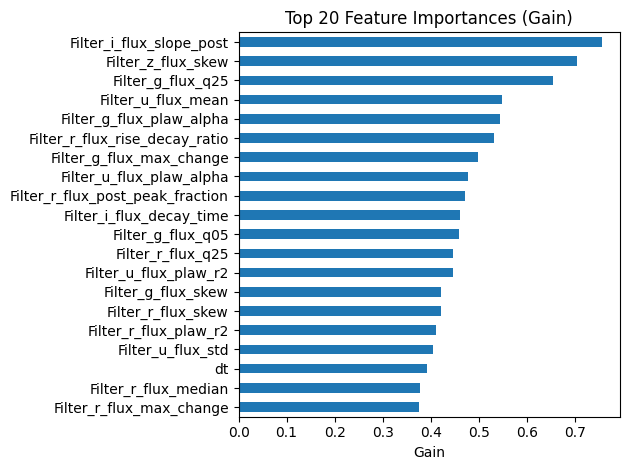

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature importance by gain
importance = model.get_booster().get_score(importance_type="gain")

# convert to DataFrame
imp_df = (
    pd.DataFrame.from_dict(importance, orient="index", columns=["gain"])
    .sort_values("gain", ascending=False)
    .head(20)
)

# plot
plt.figure(figsize=(8, 6))
imp_df[::-1].plot(kind="barh", legend=False)
plt.xlabel("Gain")
plt.title("Top 20 Feature Importances (Gain)")
plt.tight_layout()
plt.show()


In [25]:
scores = []
max_f1 = 0
best_thr = 0
for t in np.linspace(0.001, 0.15, 400):
    f1 = f1_score(y_test, pred > t)
    scores.append(f"thr {t:.3f}: f1 {f1:.3f}")
    if f1 > max_f1:
        max_f1 = f1
        best_thr = t

print(f"Best F1: {max_f1:.3f} at threshold {best_thr:.4f}")

Best F1: 0.518 at threshold 0.0357


In [26]:
# print(balanced_accuracy_score(y_test,pred))